In [1]:
import json
import os
import glob
import shutil
import sys
import string

from typing import Dict, List

from logger import _setup_child_logger, _setup_root_logger
from synthetic_metrics_plotter import (
    SyntheticMetricsPlotter,
)

from post_process_merge_jsons import(
    ENSOJSONMerger,
    CLIMJSONMerger,
    MOVSJSONMerger
)

# Set up the root logger and module level logger. The module level logger is
# a child of the root logger.
_setup_root_logger()
logger = _setup_child_logger(__name__)

In [2]:
class SyntheticPlotsParameters:
    def __init__(
            self,
            test_group: str = "cmip6.historical",
            test_prefix: str = "e3sm.historical.v3-LR",
            test_pattern: str = "v3.LR.historical",
            test_case_id: str = "v20250929",
            test_model_only: bool = False,
            test_combined: bool = False,
            test_clim_dir: str = None,
            test_clim_set: str = None,
            test_movs_dir: str = None,
            test_movs_set: str = None,
            test_enso_dir: str = None,
            test_enso_set: str = None,
            ref_group: str= "CMIP",
            ref_clim_dir: str = None,
            ref_clim_set: str = "cmip6.historical.v20250707",
            ref_movs_dir: str = None,
            ref_movs_set: str = "cmip6.historical.v20220825", 
            ref_enso_dir: str = None,
            ref_enso_set: str = "cmip6.historical.v20210620",
            clim_vars: str = "pr,prw,psl,rlds,rldscs,rltcre,rstcre,rsus,rsuscs,rlus",
            clim_regions: str = "global,ocean,land",
            movs_group: str = "cbf",
            error_norm: str = "default", 
            metric_mean_list: list = None, 
            exclude_vars: dict = None,
            exclude_models: list = None, 
            atm_modes: str = "NAM,NAO,PNA,NPO,SAM,PSA1,PSA2",
            atm_obs: str = "NOAA-20C",
            cpl_modes: str = "PDO,NPGO,AMO", 
            cpl_obs: str = "HadISST",
            diag_path: str = "./", 
            data_dir: str = "/lcrc/group/e3sm/www/pcmdi", 
            out_dir: str = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang",
            run_type: str = "model_vs_obs",
            plot_type: str = "model_vs_obs",
            save_all_data: bool = True,
            figure_format: str = "png",
            clim_viewer: bool = True,
            mova_viewer: bool = True,
            movc_viewer: bool = True,
            enso_viewer: bool = True,
            mean_group1_name: str = "CMIP",
            mean_group2_name: str = "E3SM",
            extra_groups_name: list = None,
        ):
        
        """Initialize default parameters for PCMDI synthetic plots."""
        self.figure_format = figure_format
        self.save_all_data = save_all_data
        self.run_type = run_type
        self.data_dir = data_dir
        self.out_dir = out_dir
        self.plot_type = plot_type
        
        # === Discover models ===
        self.test_group = test_group # group name 
        self.test_tableID = "Amon"
        pattern = os.path.join(data_dir, f"{test_pattern}_*")
        self.test_name = sorted([os.path.basename(d) for d in glob.glob(pattern) if os.path.isdir(d)])
        self.test_mip = [
            f"{test_prefix}.{name.split(f'{test_pattern}_')[-1]}"
            for name in self.test_name
        ]
        
        self.test_model_only = test_model_only 
        self.movs_group = movs_group
        self.error_norm = error_norm
        self.test_case_id = [test_case_id] * len(self.test_name)
        self.exclude_vars = exclude_vars 
        self.exclude_models = exclude_models
        self.mean_group1_name = mean_group1_name
        self.mean_group2_name = mean_group2_name
        self.extra_groups_name = extra_groups_name
        
        # === test sets (combined) ===
        self.test_combined = test_combined
        self.test_clim_dir = test_clim_dir 
        self.test_clim_set = test_clim_set
        self.test_movs_dir = test_movs_dir 
        self.test_movs_set = test_movs_set
        self.test_enso_dir = test_enso_dir
        self.test_enso_set = test_enso_set
        
        # === reference sets ===
        self.ref_group = ref_group
        self.ref_clim_dir = ref_clim_dir 
        self.ref_clim_set = ref_clim_set
        self.ref_movs_dir = ref_movs_dir 
        self.ref_movs_set = ref_movs_set
        self.ref_enso_dir = ref_enso_dir
        self.ref_enso_set = ref_enso_set

        # === Variable sets ===
        self.clim_vars = clim_vars.split(",")
        self.clim_regions = clim_regions.split(",")
        self.mova_modes = atm_modes.split(",")
        self.movc_modes = cpl_modes.split(",")
        self.mova_obs = atm_obs
        self.movc_obs = cpl_obs
        
        # === Viewer toggles ===
        self.clim_viewer = clim_viewer
        self.mova_viewer = mova_viewer
        self.movc_viewer = movc_viewer
        self.enso_viewer = enso_viewer

        # === Metadata ===
        self.pcmdi_webtitle = "PCMDI Synthetic Metrics"
        self.pcmdi_version = "v3.8"
        self.pcmdi_external_prefix = ""
        self.pcmdi_viewer_template = ""

        # === Derived paths ===
        self.base_test_input_path = os.path.join(
            self.data_dir,
            "%(model_name)",
            "pcmdi_diags",
            self.run_type,
            "metrics_data",
            "%(group_type)",
        )

        self.results_dir_full = os.path.join(self.out_dir, self.run_type)

    def summary(self):
        print(f"Case: {self.case}")
        print(f"Models ({len(self.model_name)}): {self.model_name}")
        print(f"Results → {self.results_dir_full}")
        
    def str2bool(self, v):
        if isinstance(v, bool):
            return v
        val = str(v).lower()
        if val in ("yes", "true", "t", "1", "y", "on"):
            return True
        elif val in ("no", "false", "f", "0", "n", "off"):
            return False
        else:
            raise argparse.ArgumentTypeError(f"Invalid boolean value: {v}")
            
    def load_metrics(self, metric_file='synthetic_metrics_list.json'):
        """Load metrics from the JSON file."""
        try:
            with open(metric_file) as f:
                return json.load(f)
        except FileNotFoundError as e:
            logging.error(f"File not found: {e}")
            raise
        except json.JSONDecodeError as e:
            logging.error(f"Error decoding JSON: {e}")
            raise
            

2026-03-11 19:32:27,095 [INFO]: 2067503628.py(<module>:170) >> generate synthetic metrics plot ...
2026-03-11 19:32:27,096 [INFO]: 2067503628.py(<module>:171) >> Running case_id=v20260212
2026-03-11 19:32:27,098 [INFO]: 2067503628.py(<module>:311) >> Generating groups=enso for case_id=v20260212
2026-03-11 19:32:27,099 [INFO]: synthetic_metrics_plotter.py(generate:267) >> Generating synthetic metrics plots ...
2026-03-11 19:32:27,099 [INFO]: synthetic_metrics_plotter.py(generate:293) >> Processing metric: enso_metric
2026-03-11 19:32:27,100 [INFO]: synthetic_metrics_plotter.py(_handle_enso_metric:472) >> Handling ENSO metrics…
2026-03-11 19:32:27,201 [INFO]: utils.py(find_latest_file_list:57) >> ENSO_perf.e3sm.historical.v3-LR_0051.vs.Tropflux.v20260212.json matched var and time patterns
2026-03-11 19:32:27,202 [INFO]: enso_metrics_reader.py(_get_test_json_path:56) >> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/climo/v3.LR.historical_0051/pcmdi_diags/model_vs_

E3SMv3-Historical
['e3sm.historical.v3-LR.0051', 'e3sm.historical.v3-LR.0091', 'e3sm.historical.v3-LR.0101', 'e3sm.historical.v3-LR.0111', 'e3sm.historical.v3-LR.0121', 'e3sm.historical.v3-LR.0131', 'e3sm.historical.v3-LR.0141', 'e3sm.historical.v3-LR.0151', 'e3sm.historical.v3-LR.0161', 'e3sm.historical.v3-LR.0171', 'e3sm.historical.v3-LR.0181', 'e3sm.historical.v3-LR.0191', 'e3sm.historical.v3-LR.0201', 'e3sm.historical.v3-LR.0211', 'e3sm.historical.v3-LR.0221', 'e3sm.historical.v3-LR.0231', 'e3sm.historical.v3-LR.0241', 'e3sm.historical.v3-LR.0251', 'e3sm.historical.v3-LR.0261', 'e3sm.historical.v3-LR.0271', 'e3sm.historical.v3-LR.0281', 'e3sm.historical.v3-LR.0291', 'e3sm.historical.v3-LR.0301', 'e3sm.historical.v3-LR.0311', 'e3sm.historical.v3-LR.0321']
['v3.LR.historical_0051', 'v3.LR.historical_0091', 'v3.LR.historical_0101', 'v3.LR.historical_0111', 'v3.LR.historical_0121', 'v3.LR.historical_0131', 'v3.LR.historical_0141', 'v3.LR.historical_0151', 'v3.LR.historical_0161', 'v3.L

2026-03-11 19:32:27,391 [INFO]: utils.py(find_latest_file_list:57) >> ENSO_perf.e3sm.historical.v3-LR_0091.vs.Tropflux.v20260212.json matched var and time patterns
2026-03-11 19:32:27,391 [INFO]: enso_metrics_reader.py(_get_test_json_path:56) >> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/climo/v3.LR.historical_0091/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf
2026-03-11 19:32:27,411 [INFO]: utils.py(find_latest_file_list:57) >> ENSO_tel.e3sm.historical.v3-LR_0091.vs.Tropflux.v20260212.json matched var and time patterns
2026-03-11 19:32:27,412 [INFO]: enso_metrics_reader.py(_get_test_json_path:56) >> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/climo/v3.LR.historical_0091/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_tel
2026-03-11 19:32:27,438 [INFO]: utils.py(find_latest_file_list:57) >> ENSO_proc.e3sm.historical.v3-LR_0091.vs.Tropflux.v20260212.json matched var and time patterns
2026-03-11 19:32:27,438 [INF

Note: The following keys were considered to be the same for v3.LR.historical_0321:
Predefined reference: GPCPv2.3, reference key in the JSON: Tropflux
Predefined reference: Tropflux, reference key in the JSON: ERA-Interim
Note: The following keys were considered to be the same for v3.LR.historical_0321:
Predefined reference: GPCPv2.3, reference key in the JSON: Tropflux
Predefined reference: Tropflux, reference key in the JSON: ERA-Interim
Predefined reference: Tropflux_GPCPv2.3, reference key in the JSON: ERA-Interim_Tropflux
Note: The following keys were considered to be the same for v3.LR.historical_0321:
Predefined reference: GPCPv2.3, reference key in the JSON: Tropflux
Predefined reference: Tropflux, reference key in the JSON: ERA-Interim
Predefined reference: Tropflux_GPCPv2.3, reference key in the JSON: ERA-Interim_Tropflux
Predefined reference: Tropflux_Tropflux, reference key in the JSON: Tropflux_ERA-Interim
Predefined reference: Tropflux_Tropflux, reference key in the JSON:

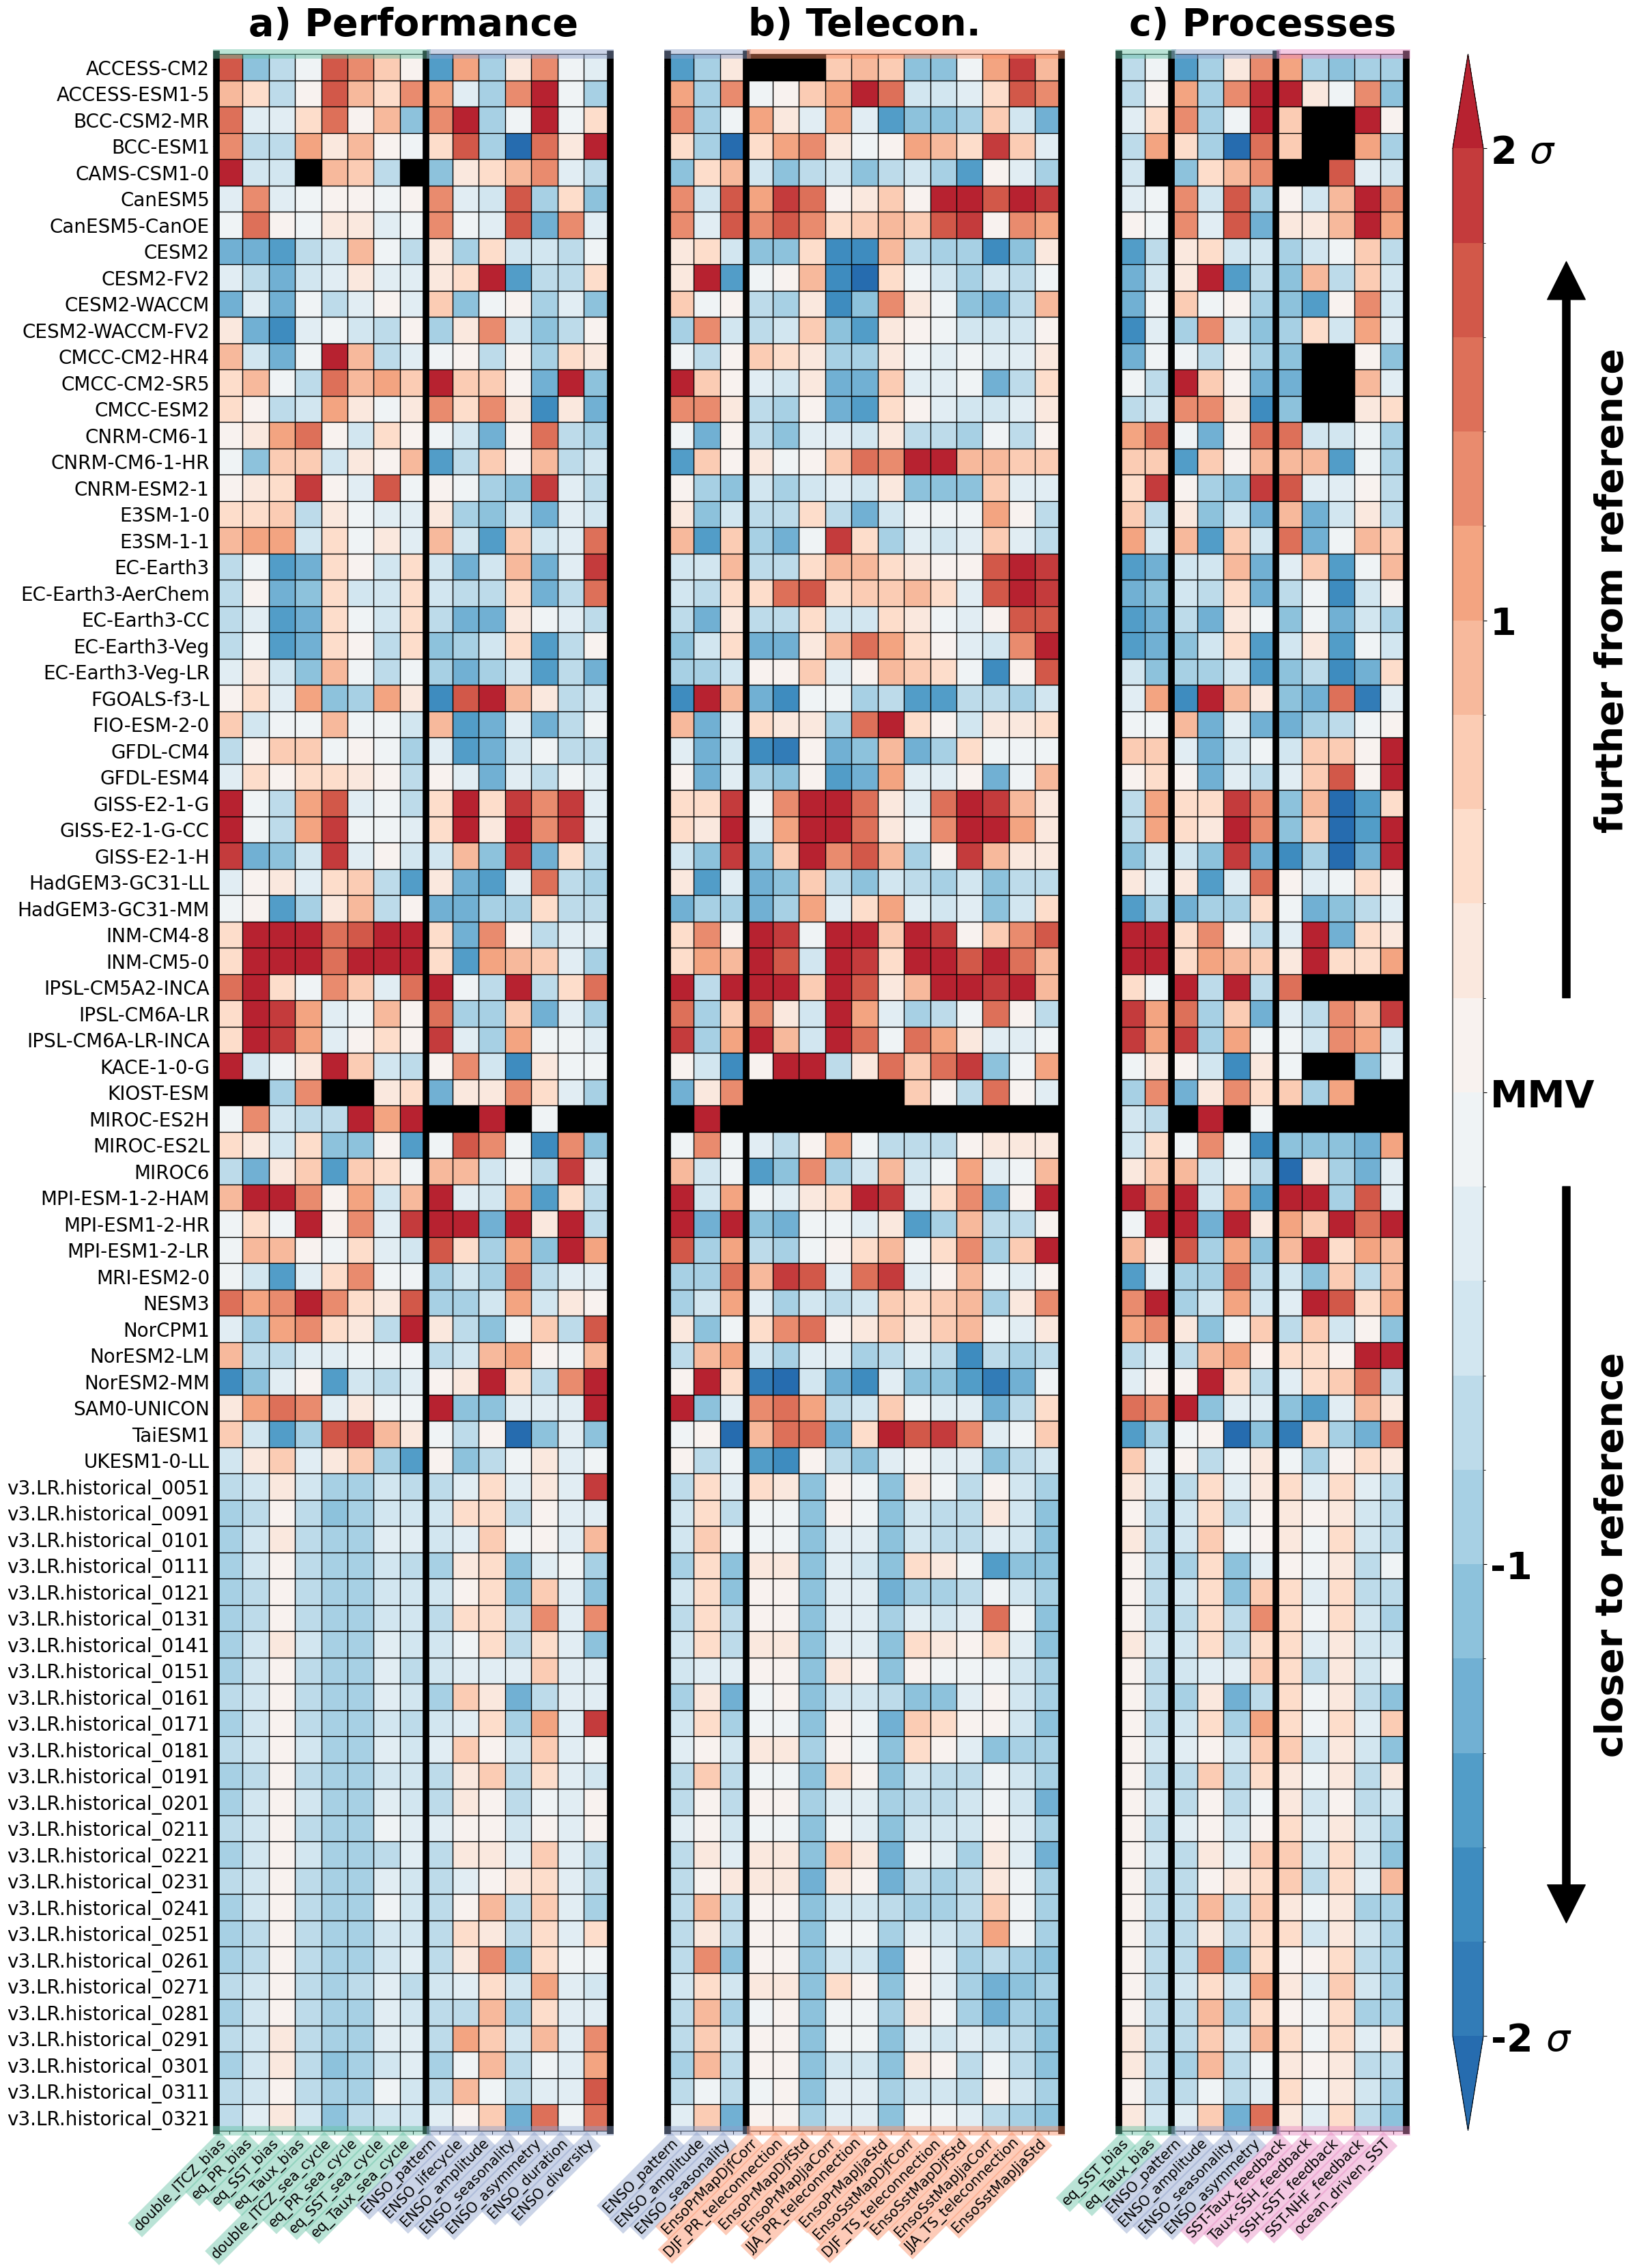

In [5]:
if __name__ == "__main__":
    """Main function to drive the entire process."""
    
    # Configuration
    
    #case_id = "v20251015" #(ERA-interim)
    #case_id = "v20260216" #(ERA-interim, revised)
    case_id = "v20260212"  #(Tropflux)
    
    run_type = 'model_vs_obs'
    diag_path = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le"
    data_path = os.path.join(diag_path, 'climo')

    out_path = os.path.join("./", 'CLIM_Metrics')

    metric_sets = 'mean_climate,variability_modes,enso_metric'.split(",")
    figure_sets = 'portrait,parcoord'.split(",")

    title_label = "E3SM versus CMIP"
    align_with_cmip = True
    ref_group = "CMIP"
    test_group = "E3SMv3-Historical"
    test_prefix = "e3sm.historical.v3-LR"
    test_pattern = "v3.LR.historical"
    test_combined = False
    test_model_only = False

    mean_group1_name = f"{ref_group} (mean)"
    mean_group2_name = f"{test_group} (mean)"

    if ref_group == "CMIP" or align_with_cmip:
        atm_modes = "NAM,NAO,PNA,NPO"
        cpl_modes = "PDO,NPGO"
    else:
        atm_modes = "NAM,NAO,PNA,NPO,SAM,PSA1,PSA2"
        cpl_modes = "PDO,NPGO,AMO"

    movs_group = "cbf"  # "eof"
    atm_obs = "NOAA-20C"
    cpl_obs = "HadISST"

    clim_vars = "pr,prw,psl,rlds,rldscs,rltcre,rstcre,rsus,rsuscs,rlus,rlut,rlutcs,rsds,rsdscs,rsut,rsutcs,rtmt,sfcWind,tas,tauu,tauv,ts,ta-200,ta-850,ua-200,ua-850,va-200,va-850,zg-500"
    clim_regions = "global"

    figure_format = "pdf"
    save_all_data = True
    error_norm = "reference"  # or "default" (selected reference)

    clim_viewer = False
    mova_viewer = False
    movc_viewer = False
    enso_viewer = True

    if ref_group == "E3SMv3-Future":
        # customize reference set
        ref_clim_dir = "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/mean_climate"
        ref_movs_dir = "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/variability_modes"
        ref_enso_dir = "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/enso_metric"
        ref_clim_set = f"e3sm.future.{case_id}"
        ref_movs_set = f"e3sm.future.{case_id}"
        ref_enso_set = f"e3sm.future.{case_id}"
    elif ref_group == "E3SMv3-Historical":
        # customize reference set
        ref_clim_dir = "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/mean_climate"
        ref_movs_dir = "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/variability_modes"
        ref_enso_dir = "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/enso_metric"
        ref_clim_set = f"e3sm.historical.{case_id}"
        ref_movs_set = f"e3sm.historical.{case_id}"
        ref_enso_set = f"e3sm.historical.{case_id}"
    else:
        # === CMIP reference sets ===
        ref_clim_dir = "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/mean_climate"
        ref_movs_dir = "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/variability_modes"
        ref_enso_dir = "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/enso_metric"
        ref_clim_set = "cmip6.historical.v20250707"
        ref_movs_set = "cmip6.historical.v20220825"
        ref_enso_set = "cmip6.historical.v20210620"

    if test_combined:
        if test_group == "E3SMv3-Future":
            # customize reference set
            test_clim_dir = "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/mean_climate"
            test_movs_dir = "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/variability_modes"
            test_enso_dir = "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/enso_metric"
            test_clim_set = f"e3sm.future.{case_id}"
            test_movs_set = f"e3sm.future.{case_id}"
            test_enso_set = f"e3sm.future.{case_id}"
        elif test_group == "E3SMv3-Historical":
            # customize reference set
            test_clim_dir = "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/mean_climate"
            test_movs_dir = "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/variability_modes"
            test_enso_dir = "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/enso_metric"
            test_clim_set = f"e3sm.historical.{case_id}"
            test_movs_set = f"e3sm.historical.{case_id}"
            test_enso_set = f"e3sm.historical.{case_id}"
    else:
        test_clim_dir = None
        test_movs_dir = None
        test_enso_dir = None
        test_clim_set = None
        test_movs_set = None
        test_enso_set = None

    ##################################
    exclude_vars = {
        "E3SM-1-0":     ["ta-850"],
        "E3SM-1-1-ECA": ["ta-850"],
        "CIESM":        ["pr"],
        "KIOST-ESM":    ["zg-500", "ta-850"],
        "GISS-E2-2-G":  ["rlutcs", "zg-500"],
    }

    exclude_models = ['E3SM-1-0', 'E3SM-1-1', 'E3SM-1-1-ECA', 'E3SM-2-0', 'E3SM-2-1']
    # exclude_models = ['E3SM-1-0','E3SM-1-1','E3SM-1-1-ECA']
    # exclude_models = None

    # extra_groups_name = ['E3SM-1-0','E3SM-2-0','E3SM-2-1'] #None
    extra_groups_name = None  # ['CIESM']

    parameters = SyntheticPlotsParameters(
        test_group=test_group,
        test_prefix=test_prefix,
        test_pattern=test_pattern,
        test_model_only=test_model_only,
        test_case_id=case_id,
        test_combined=test_combined,
        test_clim_dir=test_clim_dir,
        test_clim_set=test_clim_set,
        test_movs_dir=test_movs_dir,
        test_movs_set=test_movs_set,
        test_enso_dir=test_enso_dir,
        test_enso_set=test_enso_set,
        ref_group=ref_group,
        ref_clim_dir=ref_clim_dir,
        ref_clim_set=ref_clim_set,
        ref_movs_dir=ref_movs_dir,
        ref_movs_set=ref_movs_set,
        ref_enso_dir=ref_enso_dir,
        ref_enso_set=ref_enso_set,
        clim_vars=clim_vars,
        clim_regions=clim_regions,
        movs_group=movs_group,
        error_norm=error_norm,
        exclude_vars=exclude_vars,
        exclude_models=exclude_models,
        atm_modes=atm_modes,
        atm_obs=atm_obs,
        cpl_modes=cpl_modes,
        cpl_obs=cpl_obs,
        diag_path=diag_path,
        data_dir=data_path,
        out_dir=out_path,
        run_type=run_type,
        save_all_data=save_all_data,
        figure_format=figure_format,
        clim_viewer=clim_viewer,
        mova_viewer=mova_viewer,
        movc_viewer=movc_viewer,
        enso_viewer=enso_viewer,
    )

    print(parameters.test_group)
    print(parameters.test_mip)
    print(parameters.test_name)
    print(parameters.test_case_id)

    #########################################
    # plot synthetic figures for pcmdi metrics
    #########################################
    logger.info("generate synthetic metrics plot ...")
    logger.info(f"Running case_id={case_id}")

    test_input_path = os.path.join(
        parameters.data_dir,
        "put_model_here",
        "pcmdi_diags",
        parameters.run_type,
        "metrics_data",
        "%(group_type)",
    )

    metric_dict = json.load(open("synthetic_metrics_list.json"))

    ################################
    figure_sets = []
    if parameters.clim_viewer:
        figure_sets.append("mean_climate")
    if parameters.mova_viewer or parameters.movc_viewer:
        figure_sets.append("variability")
    if parameters.enso_viewer:
        figure_sets.append("enso")

    # --- per-figure-set configuration (titles + output dir templates) ---
    fig_idx = 0
    panel_label = "\u00A0" * 30  # f"({string.ascii_lowercase[fig_idx]})"

    cfg_map = {
        "mean_climate": {
            "title": f"{panel_label} {title_label} (Mean Climate)",
            "font_size": 40,
            "legend_lw": 1.5,
            "figure_size": (50.0, 20.0),
            "out_dir": (
                f"{out_path}/clim_vs_{error_norm}_mean_nocmip/{run_type}/{ref_group}"
                if test_model_only else
                f"{out_path}/clim_vs_{error_norm}_all_nocmip/{run_type}/{ref_group}"
            ),
        },
        "variability": {
            "title": f"{panel_label} {title_label} (Variability Modes)",
            "font_size": 40,
            "legend_lw": 1.5,
            "figure_size": (80.0, 30.0),
            "out_dir": f"{out_path}/movs_{atm_obs}_{cpl_obs}_{movs_group}_nocmip/{run_type}/{ref_group}",
        },
        "enso": {
            "title": f"{panel_label} {title_label} (ENSO)",
            "font_size": 40,
            "legend_lw": 1.5,
            "figure_size": (50.0, 20.0),
            "out_dir": f"{out_path}/enso_with_feedback_nocmip/{run_type}/{ref_group}",
        },
    }

    # -- customized enso plot setup
    enso_reduced_set = False
    enso_met_order = None
    enso_mod_order = None
    enso_sort_y_names = False
    enso_show_proj_means = False
    enso_show_ref_row = False
    enso_show_alt_obs_rows = False
    enso_highlight_cmip = True

    # --- loop over requested figure sets ---
    for fset in figure_sets:
        cfg = cfg_map.get(fset)
        if cfg is None:
            logger.warning("[SummaryMetrics]: Unknown figure set %s; skipping.", fset)
            continue

        out_dir = cfg["out_dir"]
        figure_title = cfg["title"]
        font_size = cfg["font_size"]
        legend_lw = cfg["legend_lw"]
        figure_size = cfg["figure_size"]

        plotter = SyntheticMetricsPlotter(
            # Core
            test_group=parameters.test_group,
            test_mip=parameters.test_mip,
            test_name=parameters.test_name,
            test_case_id=parameters.test_case_id,
            test_table_id=parameters.test_tableID,
            test_combined=parameters.test_combined,
            figure_format=parameters.figure_format,
            metric_dict=metric_dict,
            save_data=parameters.save_all_data,
            base_test_input_path=test_input_path,
            ref_group=parameters.ref_group,
            # Mean climate
            clim_viewer=parameters.clim_viewer,
            clim_vars=parameters.clim_vars,
            clim_regions=parameters.clim_regions,
            test_clim_dir=parameters.test_clim_dir,
            test_clim_set=parameters.test_clim_set,
            ref_clim_dir=parameters.ref_clim_dir,
            ref_clim_set=parameters.ref_clim_set,
            # MOVA
            mova_viewer=parameters.mova_viewer,
            mova_modes=parameters.mova_modes,
            mova_obs=parameters.mova_obs,
            # MOVC
            movc_viewer=parameters.movc_viewer,
            movc_modes=parameters.movc_modes,
            movc_obs=parameters.movc_obs,
            test_movs_dir=parameters.test_movs_dir,
            test_movs_set=parameters.test_movs_set,
            ref_movs_dir=parameters.ref_movs_dir,
            ref_movs_set=parameters.ref_movs_set,
            # ENSO
            enso_viewer=parameters.enso_viewer,
            ref_enso_dir=parameters.ref_enso_dir,
            ref_enso_set=parameters.ref_enso_set,
            test_enso_dir=parameters.test_enso_dir,
            test_enso_set=parameters.test_enso_set,
            # Setup for visualization
            test_model_only=parameters.test_model_only,
            movs_group=parameters.movs_group,
            exclude_vars=parameters.exclude_vars,
            exclude_models=parameters.exclude_models,
            error_norm=parameters.error_norm,
            mean_group1_name=mean_group1_name,
            mean_group2_name=mean_group2_name,
            extra_groups_name=extra_groups_name,
            reduced_set=enso_reduced_set,
            met_order=enso_met_order,
            mod_order=enso_mod_order,
            sort_y_names=enso_sort_y_names,
            show_proj_means=enso_show_proj_means,
            show_ref_row=enso_show_ref_row,
            show_alt_obs_rows=enso_show_alt_obs_rows,
            highlight_cmip=enso_highlight_cmip,
            font_size=font_size,
            legend_lw=legend_lw,
            figure_size=figure_size,
            figure_title=figure_title,
            out_dir=out_dir if out_dir is not None else parameters.results_dir_full,
        )

        logger.info(f"Generating groups={fset} for case_id={case_id}")
        print(fset)

        plotter.generate(figure_sets=[fset], debug=True)
        